#  (12) Desafio 1: Infraestrutura das Escolas Públicas da Paraíba (Censo Escolar):


**Recomendação:** Instalar a extensão *"Data Wrangler"* no vsCode, ela vai facilitar a vizualização dos dados em calcular elementos básico de estátistica descritiva.

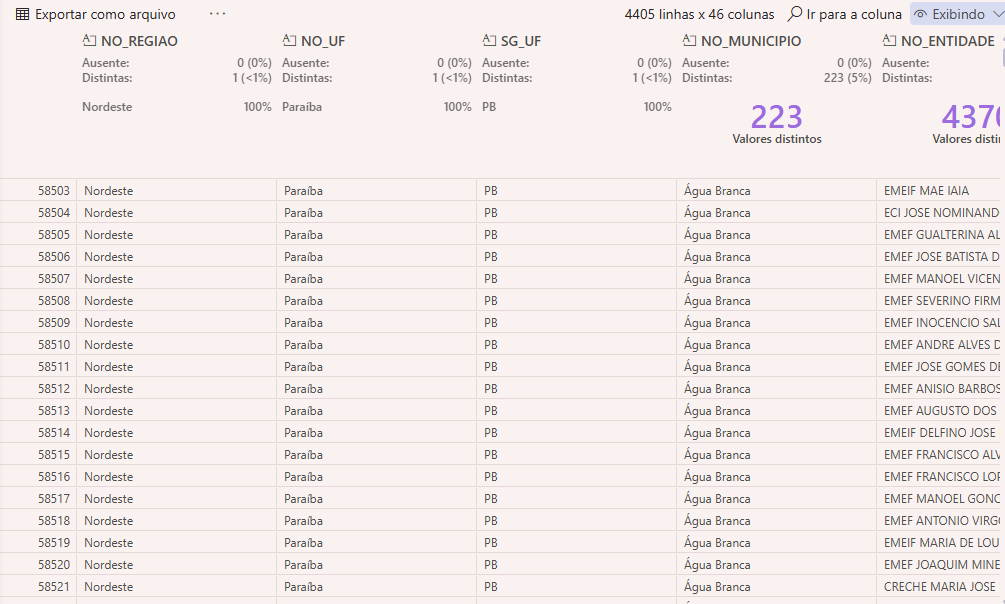
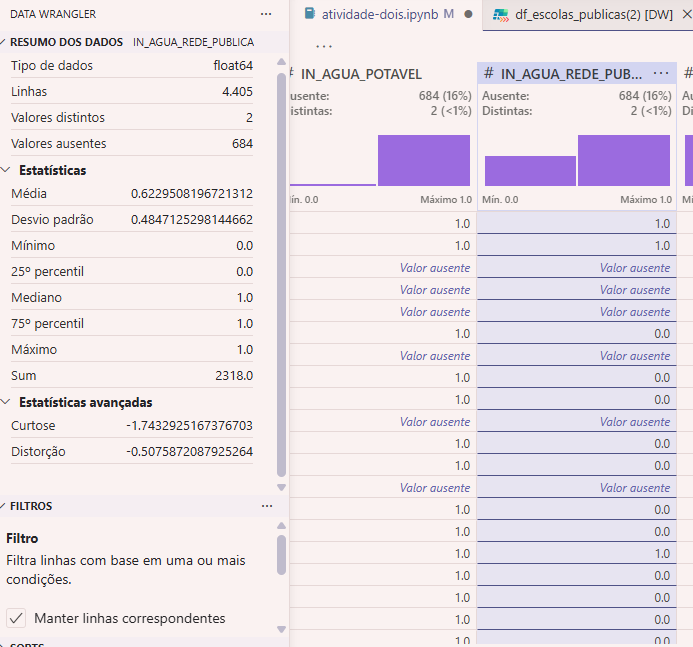

## (a) Encontrar e baixar o arquivo de microdados do Censo Escolar mais recente.

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

##  (b) Carregar os dados relevantes em um DataFrame Pandas. O Censo Escolar pode ter diversos arquivos;
foque nos que contêm informações sobre as características da escola.

In [49]:

#Definindo a lista de colunas que serão extraídas do CSV
colunas_selecionadas = [
    'NO_REGIAO', 'NO_UF','SG_UF','NO_MUNICIPIO','NO_ENTIDADE',
    'CO_ENTIDADE', 'TP_DEPENDENCIA','TP_CATEGORIA_ESCOLA_PRIVADA',
    'TP_LOCALIZACAO','TP_LOCALIZACAO_DIFERENCIADA','DS_ENDERECO',
    'NO_BAIRRO','CO_CEP',
    'IN_AGUA_POTAVEL','IN_AGUA_REDE_PUBLICA','IN_AGUA_INEXISTENTE',
    'IN_ENERGIA_REDE_PUBLICA', 'IN_ESGOTO_REDE_PUBLICA','IN_ESGOTO_INEXISTENTE',
    'IN_BANHEIRO','IN_BANHEIRO_EI','IN_BANHEIRO_PNE','IN_BIBLIOTECA',
    'IN_BIBLIOTECA_SALA_LEITURA','IN_COZINHA','IN_LABORATORIO_CIENCIAS',
    'IN_LABORATORIO_INFORMATICA','IN_QUADRA_ESPORTES',
    'IN_REFEITORIO','QT_SALAS_LEITURA',
    'IN_COMPUTADOR','IN_DESKTOP_ALUNO','QT_DESKTOP_ALUNO',
    'IN_COMP_PORTATIL_ALUNO','IN_INTERNET','IN_INTERNET_ALUNOS','QT_PROF_TRAD_LIBRAS','IN_DEPENDENCIAS_OUTRAS',
'IN_ACESSIBILIDADE_CORRIMAO',
'IN_ACESSIBILIDADE_ELEVADOR',
'IN_ACESSIBILIDADE_PISOS_TATEIS',
'IN_ACESSIBILIDADE_VAO_LIVRE',
'IN_ACESSIBILIDADE_RAMPAS',
'IN_ACESSIBILIDADE_SINAL_SONORO',
'IN_ACESSIBILIDADE_SINAL_TATIL',
'IN_ACESSIBILIDADE_SINAL_VISUAL',
]


 Selecionando dados que vão ser utilizados para maximizar a efiência da análise.


In [50]:
# df = data frame

#Lendo o arquivo para iniciar a analise, colocando os filtros apresentados em aula
df_escolas = pd.read_csv('C:\INEP\microdados_censo_escolar_2025\dados\Tabela_Escola_2025.csv',
sep=';', 
usecols=colunas_selecionadas, # Utilizando o novo nome da lista
encoding='latin1'
)

#exibindo os dados
print(df_escolas.head())

<>:4: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
<>:4: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
C:\Users\evert\AppData\Local\Temp\ipykernel_18656\2997484697.py:4: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
  df_escolas = pd.read_csv('C:\INEP\microdados_censo_escolar_2025\dados\Tabela_Escola_2025.csv',


  NO_REGIAO     NO_UF SG_UF           NO_MUNICIPIO  \
0     Norte  Rondônia    RO  Alta Floresta D'Oeste   
1     Norte  Rondônia    RO  Alta Floresta D'Oeste   
2     Norte  Rondônia    RO  Alta Floresta D'Oeste   
3     Norte  Rondônia    RO  Alta Floresta D'Oeste   
4     Norte  Rondônia    RO  Alta Floresta D'Oeste   

                    NO_ENTIDADE  CO_ENTIDADE  TP_DEPENDENCIA  \
0         EIEEF HAP BITT TUPARI     11022558               2   
1      CEEJA LUIZ VAZ DE CAMOES     11024275               2   
2           EMMEF 7 DE SETEMBRO     11024291               3   
3          EMEIEF BOA ESPERANCA     11024666               3   
4  EEEFM EURIDICE LOPES PEDROSO     11024682               2   

   TP_CATEGORIA_ESCOLA_PRIVADA  TP_LOCALIZACAO  TP_LOCALIZACAO_DIFERENCIADA  \
0                          NaN               2                          2.0   
1                          NaN               1                          0.0   
2                          NaN               2       

*(Apenas verificando as informações)*

In [51]:
df_escolas.info()

<class 'pandas.DataFrame'>
RangeIndex: 214192 entries, 0 to 214191
Data columns (total 46 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   NO_REGIAO                       214192 non-null  str    
 1   NO_UF                           214192 non-null  str    
 2   SG_UF                           214192 non-null  str    
 3   NO_MUNICIPIO                    214192 non-null  str    
 4   NO_ENTIDADE                     214192 non-null  str    
 5   CO_ENTIDADE                     214192 non-null  int64  
 6   TP_DEPENDENCIA                  214192 non-null  int64  
 7   TP_CATEGORIA_ESCOLA_PRIVADA     42454 non-null   float64
 8   TP_LOCALIZACAO                  214192 non-null  int64  
 9   TP_LOCALIZACAO_DIFERENCIADA     180540 non-null  float64
 10  DS_ENDERECO                     214191 non-null  str    
 11  NO_BAIRRO                       140598 non-null  str    
 12  CO_CEP                     

## (c) Filtrar os dados para as escolas públicas do estado da Paraíba. Identifique as variáveis que a dependência administrativa (pública) e o código do estado (UF) nos dados do Censo.

In [52]:
#uf = unidade federativa

uf_analisada = 'PB' #Posto como variavel para facilitar na analise de outros estados
df_uf = df_escolas[df_escolas['SG_UF'] == uf_analisada] 
print(f"Dados carregados para o estado: {uf_analisada}")
print(f"Quantidade de escolas filtradas: {len(df_uf)}")
print(df_uf.head())

Dados carregados para o estado: PB
Quantidade de escolas filtradas: 5641
      NO_REGIAO    NO_UF SG_UF NO_MUNICIPIO                    NO_ENTIDADE  \
58503  Nordeste  Paraíba    PB  Água Branca                 EMEIF MAE IAIA   
58504  Nordeste  Paraíba    PB  Água Branca             ECI JOSE NOMINANDO   
58505  Nordeste  Paraíba    PB  Água Branca  EMEF GUALTERINA ALENCAR VIDAL   
58506  Nordeste  Paraíba    PB  Água Branca         EMEF JOSE BATISTA DIAS   
58507  Nordeste  Paraíba    PB  Água Branca      EMEF MANOEL VICENTE LEITE   

       CO_ENTIDADE  TP_DEPENDENCIA  TP_CATEGORIA_ESCOLA_PRIVADA  \
58503     25033158               3                          NaN   
58504     25033204               2                          NaN   
58505     25033301               3                          NaN   
58506     25033352               3                          NaN   
58507     25033395               3                          NaN   

       TP_LOCALIZACAO  TP_LOCALIZACAO_DIFERENCIADA  ...

In [53]:
df_escolas_publicas = df_uf[df_uf['TP_DEPENDENCIA'] != 4]
print(df_escolas_publicas)

      NO_REGIAO    NO_UF SG_UF NO_MUNICIPIO  \
58503  Nordeste  Paraíba    PB  Água Branca   
58504  Nordeste  Paraíba    PB  Água Branca   
58505  Nordeste  Paraíba    PB  Água Branca   
58506  Nordeste  Paraíba    PB  Água Branca   
58507  Nordeste  Paraíba    PB  Água Branca   
...         ...      ...   ...          ...   
64139  Nordeste  Paraíba    PB  Vieirópolis   
64140  Nordeste  Paraíba    PB  Vieirópolis   
64141  Nordeste  Paraíba    PB       Zabelê   
64142  Nordeste  Paraíba    PB       Zabelê   
64143  Nordeste  Paraíba    PB       Zabelê   

                                      NO_ENTIDADE  CO_ENTIDADE  \
58503                              EMEIF MAE IAIA     25033158   
58504                          ECI JOSE NOMINANDO     25033204   
58505               EMEF GUALTERINA ALENCAR VIDAL     25033301   
58506                      EMEF JOSE BATISTA DIAS     25033352   
58507                   EMEF MANOEL VICENTE LEITE     25033395   
...                                    

## (d) Identificar os maiores desafios em termos de infraestrutura. Para isso, selecione variáveis que
representam aspectos da infraestrutura (ex: acesso à água, esgoto, energia elétrica, internet, biblioteca,
laboratórios, quadra de esportes, acessibilidade, etc.).

- fatores globais de identificação:

In [ ]:
#dados gerais usados para o restante da analise

cod_escola = df_escolas_publicas['CO_ENTIDADE'] #Vamos usar o codigo para identificar as redes de ensino
nome_escola = df_escolas_publicas['NO_ENTIDADE']
responsa_administrativa = df_escolas_publicas['TP_DEPENDENCIA'] 
total_escolas = len(df_escolas_publicas)


4405


- Acesso aos recursos básicos: agua potável, energia eletrica

In [55]:

eletricidade = df_escolas_publicas['IN_ENERGIA_REDE_PUBLICA'].sum()
agua_potavel = df_escolas_publicas['IN_AGUA_POTAVEL'].sum()
esgoto = df_escolas_publicas['IN_ESGOTO_REDE_PUBLICA'].sum()

# Mostrando os resultados

print(f"Das {total_escolas} escolas publicas, de admnistração: Federal, Estadual, Municipal")
print(f"Tem eletricidade: {eletricidade}")
print(f"Tem água abastecimento de agua: {agua_potavel}")
print(f"Tem esgoto: {esgoto}")


Das 4405 escolas publicas, de admnistração: Federal, Estadual, Municipal
Tem eletricidade: 3698.0
Tem água abastecimento de agua: 3699.0
Tem esgoto: 1541.0


Identificando que são os responsaveis administrativos por essas unidade de ensino:  

In [56]:

#Agrupando escolas por responsabilidade administrativa: 1 - federal, 2- estadual 3- municipal
# existência do recurso: 0 - não e 1 - sim


#cruzando as tabelas para saber quais entes administrativos são responsaveis pelas escolas sem agua
tabela_agua = pd.crosstab(
    df_escolas_publicas['TP_DEPENDENCIA'],
    df_escolas_publicas['IN_AGUA_REDE_PUBLICA']
)

print(tabela_agua)

tabela_eletricidade = pd.crosstab(
    df_escolas_publicas['TP_DEPENDENCIA'],
    df_escolas_publicas['IN_ENERGIA_REDE_PUBLICA']
)

print(tabela_eletricidade)

tabela_esgoto = pd.crosstab(
    df_escolas_publicas['TP_DEPENDENCIA'],
    df_escolas_publicas['IN_ESGOTO_REDE_PUBLICA']
)

print(tabela_esgoto)

IN_AGUA_REDE_PUBLICA   0.0   1.0
TP_DEPENDENCIA                  
1                        4    22
2                       68   534
3                     1331  1762
IN_ENERGIA_REDE_PUBLICA  0.0   1.0
TP_DEPENDENCIA                    
1                          0    26
2                          7   595
3                         16  3077
IN_ESGOTO_REDE_PUBLICA   0.0   1.0
TP_DEPENDENCIA                    
1                          9    17
2                        200   402
3                       1971  1122


## (e) Calcule a porcentagem de escolas que não possuem cada um desses itens de infraestrutura ou que apresentam alguma deficiência.

In [66]:
#verificando a porcentagem de escola com acesso aos recursos: agua, eletricidade, esgoto

percentual_com_agua = df_escolas_publicas['IN_AGUA_REDE_PUBLICA'].mean()
percentual_com_eletriciade = df_escolas_publicas['IN_ENERGIA_REDE_PUBLICA'].mean()
percentual_com_esgoto = df_escolas_publicas['IN_ESGOTO_REDE_PUBLICA']. mean()
print(f"{percentual_com_agua:.2f}, {percentual_com_eletriciade:.2f}, {percentual_com_esgoto:.2f}")

0.62, 0.99, 0.41


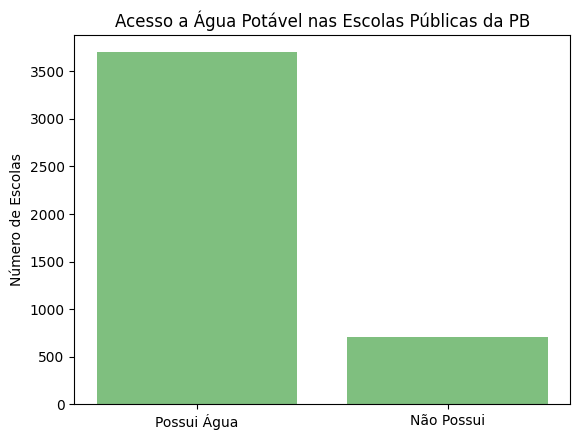

In [ ]:
#Gerando gráfico das escolas sem abastecimento de agua pela rede publica

total_sem_agua = total_escolas - agua_potavel

# Criando as listas para o gráfico
nomes_barras = ['Possui Água', 'Não Possui']
valores_barras = [agua_potavel, total_sem_agua]
# desenvolvendo o gráfico
plt.bar(nomes_barras, valores_barras, color='green', alpha=0.5)

plt.title('Acesso a Água Potável nas Escolas Públicas da PB')
plt.ylabel('Número de Escolas')



plt.show()

- Acesso a rede de fornecimento publico de eletricidade:

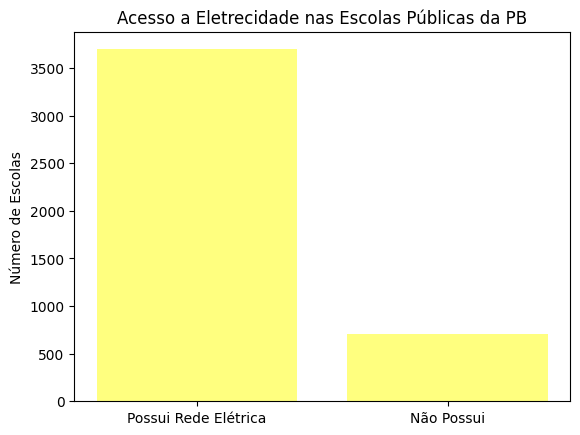

In [ ]:
total_sem_eletricidade = total_escolas - eletricidade

# Criamos as listas para o gráfico
nomes_barras = ['Possui Rede Elétrica', 'Não Possui']
valores_barras = [eletricidade, total_sem_eletricidade]

# desenvolvendo o gráfico
plt.bar(nomes_barras, valores_barras, color='yellow', alpha=0.5)

plt.title('Acesso a Eletrecidade nas Escolas Públicas da PB')
plt.ylabel('Número de Escolas')



plt.show()

Text(0.5, 0, 'Total de escolas')

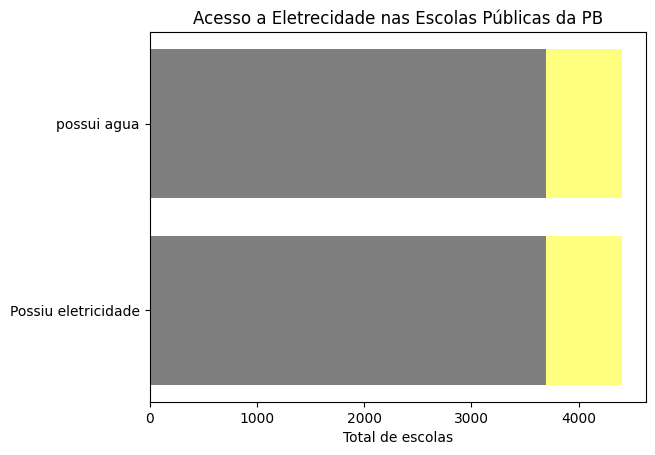

In [ ]:
total_sem_eletricidade = total_escolas - eletricidade

# Criamos as listas para o gráfico
nomes_barras = ['Possiu eletricidade', 'possui agua']
valores_eletricidade = [eletricidade]
valores_agua = [agua_potavel]
# desenvolvendo o gráfico
plt.barh(nomes_barras, valores_eletricidade, color='yellow', alpha=0.5)
plt.barh(nomes_barras, valores_agua, color='blue')
plt.barh(nomes_barras, total_escolas, color='yellow', alpha=0.5)

plt.title('Acesso a Eletrecidade nas Escolas Públicas da PB')
plt.xlabel('Total de escolas')


## (f) Apresente de forma clara quais são os maiores desafios de infraestrutura para as escolas públicas da Paraíba, baseando-se nos percentuais calculados.

Existem considerações importantes que devem ser feitas para a análise dos dados. Já foi abordado em sala de aula, refere-se à falta de precisão na definição sobre a existência ou não de determinados recursos dentro da unidade de ensino. Por exemplo, a escola pode afirmar possuir uma quadra de esportes quando, na realidade, a suposta “quadra” corresponde aos fundos de um auditório, sem a estrutura adequada para a prática esportiva, como cobertura, piso apropriado e proteções necessárias. Da mesma forma, pode declarar possuir uma biblioteca quando, na prática, dispõe apenas de uma mesa com cerca de dez livros expostos.

Analisando as informações sobre recursos básicos, é possível identificar negligências em todos os âmbitos da administração pública, especialmente por parte do *Estado e dos municípios*, que não fornecem a infraestrutura mínima necessária para a construção de um ambiente adequado de aprendizagem.

Com base nas dados é possível afirmar que os desafios começam na infraestrutura básica. Pois, apenas 62% das unidades de ensino dispões de agua encanda e apenas 41% tem acesso a esgoto encanado, entrantanto não significa dizer que não tenham acesso a outros meios de sanemaento basico.  

Vale observar que, entre as escolas analisadas, ao menos 6 **não possuem** sequer abastecimento de água proveniente da rede pública, sistema de esgoto ou acesso à rede elétrica. Dessas instituições, 4 oferecem Educação de Jovens e Adultos (EJA), atendendo pessoas que não tiveram acesso à educação básica ou ao ensino médio no período considerado adequado de suas vidas. (foi utilizado os filtros no Data Wrangler para essa constatação).

Ao consultar o nome dessas escolas, verifica-se que as 6 instituições somam mais de 300 matrículas (algumas delas como matriculas especiais, acredito que sejam pessoas que carecem de algum acompanhamento especial), sendo que 2 delas estão localizadas em Catolé do Rocha.

Por fim, para ampliar a precisão dessa análise, seria interessante:

- Mapear as instituições que não possuem infraestrutura básica, identificando seus códigos e endereços;
- Identificar o nível do ente responsável por cada instituição (Federal, Estadual ou Municipal);
- Verificar quantas pessoas estudam nessas instituições, considerando que a discussão não se refere apenas às estruturas físicas, mas principalmente ao atendimento das necessidades básicas dos estudantes;
- Elaborar um relatório mais aprofundado, contendo análises detalhadas dos dados obtidos.






# (13) Desafio 2: Análise da PNAD Contínua na Paraíba:
Para esta questão, você precisará buscar os dados mais recentes da Pesquisa Nacional por Amostra de Domicílios Contínua (PNAD Contínua) do IBGE. 